In [1]:
import numpy as np
import pandas as pd

import time
from tqdm import tqdm
from tvDatafeed import TvDatafeed, Interval

def get_data_from_tradingview(
    tickers: list[str],
    interval: Interval, # tvDatafeed.Interval 객체 형태
    exchange: list[str],
    n_bars: int, # 충분히 큰 수. Tradingview는 기간이 아닌 candle bar의 개수로 호출 가능
    column: str | None = None,
    verbose: bool = True, # 종목을 얼마만큼 호출 성공했는지 progress bar로 표현
    num_trials: int = 5, # 호출 실패 시 재시도 횟수
    multi_level_index: bool = True, # yfinance에서의 attribute와 동일한 기능
    tz_cleansing: bool = False,
    session_duration_map: dict[str, tuple[int, int]] | None = None,
    duplicate_index_method: str = "last",  # "last", "first", "mean"
) -> pd.DataFrame:
    """
    TradingView(tvDatafeed)로부터 가격데이터 import

    Params
    - column:
        * str  : 해당 컬럼만 반환 (columns=tickers)
        * None : OHLCV 전체 반환

    - multi_level_index:
        * True  : columns=MultiIndex (ticker, field)  -> ("AAPL","close") 형태
        * False : columns=MultiIndex (field, ticker)  -> data["close"] 로 모든 종목 접근 가능

    - tz_cleansing:
        * True  : 인덱스를 날짜 단위로 정규화
        * False : 원본 인덱스 유지

    - session_duration_map:
        * None : 인덱스 변경 없음
        * dict : 거래소별 open -> close 시간 차이
            예:
            {
                "NASDAQ": (6, 30),
                "NYSE": (6, 30),
                "KRX": (6, 30),
                "TSE": (6, 0),
            }

    - duplicate_index_method:
        * "last"  : 같은 timestamp가 여러 개 있으면 마지막 값 사용
        * "first" : 같은 timestamp가 여러 개 있으면 첫 번째 값 사용
        * "mean"  : 같은 timestamp가 여러 개 있으면 평균값 사용

    Notes
    - column이 str이면 multi_level_index 설정은 의미가 거의 없고, 그냥 (columns=tickers)로 반환.
    """

    def _shift_index_by_session_duration(
        idx: pd.Index,
        exch: str,
        session_duration_map: dict[str, tuple[int, int]] | None,
    ) -> pd.DatetimeIndex:
        idx = pd.to_datetime(idx)

        if getattr(idx, "tz", None) is not None:
            idx = idx.tz_localize(None)

        if session_duration_map is None:
            return pd.DatetimeIndex(idx)

        if exch not in session_duration_map:
            return pd.DatetimeIndex(idx)

        hours, minutes = session_duration_map[exch]
        delta = pd.Timedelta(hours=hours, minutes=minutes)

        return pd.DatetimeIndex(idx + delta)

    def _remove_duplicate_index(obj: pd.Series | pd.DataFrame):
        """
        index가 중복된 Series/DataFrame을 정리.
        TradingView continuous futures, timezone cleansing, session shift 이후
        동일 날짜/시간 index가 생길 수 있으므로 concat 전에 반드시 처리.
        """
        if not obj.index.has_duplicates:
            return obj

        if duplicate_index_method == "last":
            return obj.groupby(level=0).last()

        elif duplicate_index_method == "first":
            return obj.groupby(level=0).first()

        elif duplicate_index_method == "mean":
            return obj.groupby(level=0).mean(numeric_only=True)

        else:
            raise ValueError(
                "duplicate_index_method must be one of ['last', 'first', 'mean']"
            )

    tv = TvDatafeed()
    iterator = tqdm(list(zip(tickers, exchange)), disable=not verbose)

    ohlcv_cols = ["open", "high", "low", "close", "volume"]
    frames: list[pd.DataFrame] = []
    series_list: list[pd.Series] = []

    for ticker, exch in iterator:
        got = False

        for attempt in range(num_trials):
            try:
                temp = tv.get_hist(
                    symbol=ticker,
                    exchange=exch,
                    interval=interval,
                    n_bars=n_bars,
                )

                if temp is None or temp.empty:
                    raise ValueError(f"Empty data returned for {ticker} ({exch}).")

                temp.columns = [c.lower() for c in temp.columns]
                temp.index = pd.to_datetime(temp.index)

                # 거래소별 open -> close shift
                if session_duration_map is not None:
                    temp.index = _shift_index_by_session_duration(
                        idx=temp.index,
                        exch=exch,
                        session_duration_map=session_duration_map,
                    )

                elif tz_cleansing:
                    temp.index = pd.to_datetime(temp.index.strftime("%Y-%m-%d"))

                else:
                    if getattr(temp.index, "tz", None) is not None:
                        temp.index = temp.index.tz_localize(None)

                # timezone cleansing, session shift, continuous futures rollover 등으로
                # 동일 timestamp가 생기는 경우를 여기서 제거
                temp = _remove_duplicate_index(temp)

                if column is None:
                    use_cols = [c for c in ohlcv_cols if c in temp.columns]
                    temp2 = temp[use_cols].copy()

                    # OHLCV DataFrame 기준으로도 한 번 더 방어
                    temp2 = _remove_duplicate_index(temp2)

                    temp2.columns = pd.MultiIndex.from_product(
                        [[ticker], temp2.columns.tolist()],
                        names=["ticker", "field"],
                    )
                    frames.append(temp2)

                else:
                    col = column.lower()
                    if col not in temp.columns:
                        raise KeyError(
                            f"Column '{column}' not in data columns for {ticker}: {list(temp.columns)}"
                        )

                    series = temp[col].copy()
                    series.name = ticker

                    # pd.concat(series_list, axis=1)에서 터지는 것을 방지
                    series = _remove_duplicate_index(series)

                    series_list.append(series)

                got = True
                break

            except Exception as e:
                if attempt < num_trials - 1:
                    time.sleep(1)
                else:
                    print(f"[FAIL] {ticker} ({exch}) after {num_trials} trials: {e}")

        if not got:
            continue

    if column is not None:
        if not series_list:
            return pd.DataFrame()

        # concat 직전 최종 방어
        series_list = [_remove_duplicate_index(s) for s in series_list]

        return pd.concat(series_list, axis=1).sort_index()

    if not frames:
        return pd.DataFrame()

    # OHLCV 전체 반환 시 concat 직전 최종 방어
    frames = [_remove_duplicate_index(f) for f in frames]

    out = pd.concat(frames, axis=1).sort_index()

    if multi_level_index:
        return out.sort_index(axis=1)

    out.columns = out.columns.swaplevel(0, 1)
    return out.sort_index(axis=1)

### US Yields

In [8]:
us_interest_rate_symbol = {
    # =========================================================
    # 1. Federal Reserve Policy & Overnight Funding Rates
    # =========================================================
    'DFF': 'FRED',       # Effective Federal Funds Rate
    'EFFR': 'FRED',      # Effective Federal Funds Rate
    'SOFR': 'FRED',      # Secured Overnight Financing Rate
    'IORB': 'FRED',      # Interest Rate on Reserve Balances
    'OBFR': 'FRED',      # Overnight Bank Funding Rate
    'DPRIME': 'FRED',    # Bank Prime Loan Rate

    # =========================================================
    # 2. US Treasury Constant Maturity Rates
    # =========================================================
    'DGS1MO': 'FRED',    # 1-Month Treasury Yield
    'DGS3MO': 'FRED',    # 3-Month Treasury Yield
    'DGS6MO': 'FRED',    # 6-Month Treasury Yield
    'DGS1': 'FRED',      # 1-Year Treasury Yield
    'DGS2': 'FRED',      # 2-Year Treasury Yield
    'DGS3': 'FRED',      # 3-Year Treasury Yield
    'DGS5': 'FRED',      # 5-Year Treasury Yield
    'DGS7': 'FRED',      # 7-Year Treasury Yield
    'DGS10': 'FRED',     # 10-Year Treasury Yield
    'DGS20': 'FRED',     # 20-Year Treasury Yield
    'DGS30': 'FRED',     # 30-Year Treasury Yield

    # =========================================================
    # 3. Treasury Real Yields — TIPS
    # =========================================================
    'DFII5': 'FRED',     # 5-Year Treasury Inflation-Indexed Yield
    'DFII7': 'FRED',     # 7-Year Treasury Inflation-Indexed Yield
    'DFII10': 'FRED',    # 10-Year Treasury Inflation-Indexed Yield
    'DFII20': 'FRED',    # 20-Year Treasury Inflation-Indexed Yield
    'DFII30': 'FRED',    # 30-Year Treasury Inflation-Indexed Yield

    # =========================================================
    # 4. Breakeven Inflation Rates
    # =========================================================
    'T5YIE': 'FRED',     # 5-Year Breakeven Inflation Rate
    'T10YIE': 'FRED',    # 10-Year Breakeven Inflation Rate
    'T5YIFR': 'FRED',    # 5-Year, 5-Year Forward Inflation Expectation
    #'T20YIEM': 'FRED',   # 20-Year Breakeven Inflation Rate, Monthly
    #'T30YIEM': 'FRED',   # 30-Year Breakeven Inflation Rate, Monthly

    # =========================================================
    # 5. Moody's Seasoned Corporate Bond Yields
    # =========================================================
    'DAAA': 'FRED',      # Moody's Seasoned Aaa Corporate Bond Yield
    'DBAA': 'FRED',      # Moody's Seasoned Baa Corporate Bond Yield
    'AAA10Y': 'FRED',    # Aaa Corporate Yield Spread over 10Y Treasury
    'BAA10Y': 'FRED',    # Baa Corporate Yield Spread over 10Y Treasury

    # =========================================================
    # 6. ICE BofA Corporate Bond Effective Yields
    # =========================================================
    'BAMLC0A0CMEY': 'FRED',      # US Investment Grade Corporate Yield
    'BAMLC0A1CAAAEY': 'FRED',    # AAA US Corporate Effective Yield
    'BAMLC0A2CAAEY': 'FRED',     # AA US Corporate Effective Yield
    'BAMLC0A3CAEY': 'FRED',      # A US Corporate Effective Yield
    'BAMLC0A4CBBBEY': 'FRED',    # BBB US Corporate Effective Yield
    'BAMLH0A0HYM2EY': 'FRED',    # US High Yield Effective Yield

    # =========================================================
    # 7. Corporate Credit Spreads — OAS
    # =========================================================
    'BAMLC0A0CM': 'FRED',        # US Corporate Investment Grade OAS
    'BAMLC0A1CAAA': 'FRED',      # AAA US Corporate OAS
    'BAMLC0A2CAA': 'FRED',       # AA US Corporate OAS
    'BAMLC0A3CA': 'FRED',        # A US Corporate OAS
    'BAMLC0A4CBBB': 'FRED',      # BBB US Corporate OAS
    'BAMLH0A0HYM2': 'FRED',      # US High Yield OAS
    'BAMLH0A1HYBB': 'FRED',      # BB US High Yield OAS
    'BAMLH0A2HYB': 'FRED',       # Single-B US High Yield OAS
    'BAMLH0A3HYC': 'FRED',       # CCC & Lower US High Yield OAS

    # =========================================================
    # 8. Mortgage Rate
    # =========================================================
    'MORTGAGE30US': 'FRED',      # 30-Year Fixed Rate Mortgage Average
    'MORTGAGE15US': 'FRED',      # 15-Year Fixed Rate Mortgage Average
}

In [9]:
usyield_data = get_data_from_tradingview(
    tickers = list(us_interest_rate_symbol.keys()),
    interval = Interval.in_daily,
    exchange = list(us_interest_rate_symbol.values()),
    n_bars = 13000,
    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

100%|██████████| 46/46 [00:45<00:00,  1.02it/s]
C:\Users\krm\AppData\Local\Temp\ipykernel_19476\882957812.py:200: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  out = pd.concat(frames, axis=1).sort_index()


In [11]:
usy = usyield_data.xs('close', level = 1, axis = 1)

In [12]:
us_interest_rate_symbol_map = {
    # Policy / Money Market
    'DFF': 'FEDFUNDS',
    'EFFR': 'EFFR',
    'SOFR': 'SOFR',
    'IORB': 'IORB',
    'OBFR': 'OBFR',
    'DPRIME': 'PRIME',

    # US Treasury Yield
    'DGS1MO': 'USTB1M',
    'DGS3MO': 'USTB3M',
    'DGS6MO': 'USTB6M',
    'DGS1': 'USTB1Y',
    'DGS2': 'USTB2Y',
    'DGS3': 'USTB3Y',
    'DGS5': 'USTB5Y',
    'DGS7': 'USTB7Y',
    'DGS10': 'USTB10Y',
    'DGS20': 'USTB20Y',
    'DGS30': 'USTB30Y',

    # Treasury Real Yield
    'DFII5': 'USTB5YRY',
    'DFII7': 'USTB7YRY',
    'DFII10': 'USTB10YRY',
    'DFII20': 'USTB20YRY',
    'DFII30': 'USTB30YRY',

    # Breakeven Inflation
    'T5YIE': 'BEI5Y',
    'T10YIE': 'BEI10Y',
    'T5YIFR': 'BEI5Y5Y',
    #'T20YIEM': 'BEI20Y',
    #'T30YIEM': 'BEI30Y',

    # Moody's Corporate Yield / Spread
    'DAAA': 'MOODYAAAY',
    'DBAA': 'MOODYBAAY',
    'AAA10Y': 'AAA10YSP',
    'BAA10Y': 'BAA10YSP',

    # Corporate Effective Yield
    'BAMLC0A0CMEY': 'USIGY',
    'BAMLC0A1CAAAEY': 'USAAAY',
    'BAMLC0A2CAAEY': 'USAAY',
    'BAMLC0A3CAEY': 'USAY',
    'BAMLC0A4CBBBEY': 'USBBBY',
    'BAMLH0A0HYM2EY': 'USHYY',

    # Corporate OAS
    'BAMLC0A0CM': 'USIGOAS',
    'BAMLC0A1CAAA': 'USAAAOAS',
    'BAMLC0A2CAA': 'USAAOAS',
    'BAMLC0A3CA': 'USAOAS',
    'BAMLC0A4CBBB': 'USBBBOAS',
    'BAMLH0A0HYM2': 'USHYOAS',
    'BAMLH0A1HYBB': 'USBBHYOAS',
    'BAMLH0A2HYB': 'USBHYOAS',
    'BAMLH0A3HYC': 'USCCCOAS',

    # Mortgage
    'MORTGAGE30US': 'MTG30Y',
    'MORTGAGE15US': 'MTG15Y',
}

In [13]:
usy.columns = us_interest_rate_symbol_map.values()

In [16]:
usy.to_excel('US Yield Rate.xlsx')

### China Index

In [37]:
china_csi300_sector_symbol = {
    '000001' : 'SSE', # Shanghai Composite Index
    '399001' : 'SZSE', # Shenzhen Component Index
    '399006' : 'SZSE', # ChiNext Index
    'HSI' : 'HSI', # Hang Seng Index
    'HSTECH' : 'HSI', # Hang Seng Tech Index
    '000300': 'SSE',  # CSI 300 Index
    '000908': 'SSE',  # CSI 300 Energy Index
    '000909': 'SSE',  # CSI 300 Materials Index
    '000910': 'SSE',  # CSI 300 Industrials Index
    '000911': 'SSE',  # CSI 300 Consumer Discretionary Index
    '000912': 'SSE',  # CSI 300 Consumer Staples Index
    '000913': 'SSE',  # CSI 300 Health Care Index
    '000914': 'SSE',  # CSI 300 Financials Index
    '000915': 'SSE',  # CSI 300 Information Technology Index
    '000916': 'SSE',  # CSI 300 Telecommunication Services Index
    '000917': 'SSE',  # CSI 300 Utilities Index
    '000952': 'SSE',  # CSI 300 Real Estates Index
}

In [38]:
china_csi300_data = get_data_from_tradingview(
    tickers = list(china_csi300_sector_symbol.keys()),
    interval = Interval.in_daily,
    exchange = list(china_csi300_sector_symbol.values()),
    n_bars = 13000,
    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

100%|██████████| 17/17 [00:48<00:00,  2.85s/it]
C:\Users\krm\AppData\Local\Temp\ipykernel_26584\882957812.py:200: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  out = pd.concat(frames, axis=1).sort_index()


In [39]:
china_csi300_symbol_map = {
    '000001' : 'SSEC', # Shanghai Composite Index
    '399001' : 'SZSE', # Shenzhen Component Index
    '399006' : 'CHINEXT', # ChiNext Index
    'HSI' : 'HSI', # Hang Seng Index
    'HSTECH' : 'HSTECH', # Hang Seng Tech Index
    '000300': 'CSI300',
    '000908': 'CSI30010',  # Energy
    '000909': 'CSI30015',  # Materials
    '000910': 'CSI30020',  # Industrials
    '000911': 'CSI30025',  # Consumer Discretionary
    '000912': 'CSI30030',  # Consumer Staples
    '000913': 'CSI30035',  # Health Care
    '000914': 'CSI30040',  # Financials
    '000915': 'CSI30045',  # Information Technology
    '000916': 'CSI30050',  # Communication Services
    '000917': 'CSI30055',  # Utilities
    '000952': 'CSI30060',  # Real Estate
}

<Axes: xlabel='datetime'>

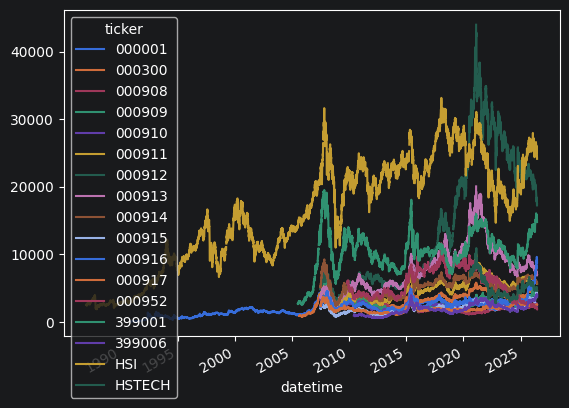

In [40]:
china_csi300_data.xs('close',level = 1, axis = 1).plot()

In [42]:
with pd.ExcelWriter('china_index_data.xlsx') as writer:
    for symbol in tqdm(list(china_csi300_sector_symbol.keys())):
        china_csi300_data[symbol].dropna(axis=0, how="all").to_excel(
            writer,
            sheet_name = china_csi300_symbol_map[symbol]
        )

 24%|██▎       | 4/17 [00:01<00:02,  4.71it/s]Exception ignored in: <function ZipFile.__del__ at 0x000002461A89A0C0>
Traceback (most recent call last):
  File "C:\Users\krm\AppData\Local\Programs\Python\Python313\Lib\zipfile\__init__.py", line 1988, in __del__
    self.close()
  File "C:\Users\krm\AppData\Local\Programs\Python\Python313\Lib\zipfile\__init__.py", line 2005, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file
100%|██████████| 17/17 [00:03<00:00,  5.63it/s]


### TOPIX (Japan Market)

In [8]:
japan_index_symbol = {
    'TOPIX' : 'TSE', # TOPIX
    'TOPIX100' : 'TSE', # TOPIX 100
    'TOPIX500' : 'TSE', # TOPIX 500
    'TOPIX1000' : 'TSE', # TOPIX 1000
    #'TC' : 'TSE', # TOPIX Composite
    'T17B' : 'TSE', # TOPIX-17 Banks
    'T17FD' : 'TSE', # TOPIX-17 Foods
    'T17RT' : 'TSE', # TOPIX-17 Retail Trade
    'T17M' : 'TSE', # TOPIX-17 Machinery
    'T17RE' : 'TSE', # TOPIX-17 Real Estate
    'T17ER' : 'TSE', # TOPIX-17 Energy Resources
    'T17FIN' : 'TSE', # TOPIX-17 Financials
    'T17PHR' : 'TSE', # TOPIX-17 Pharmaceutical
    'T17EPG' : 'TSE', # TOPIX-17 Electric Power & gas
    'T17ISO' : 'TSE', # TOPIX-17 IT & Services & Others
    'T17SNM' : 'TSE', # TOPIX-17 Steel & Non-ferrous metals
    'T17RMC' : 'TSE', # TOPIX-17 Raw Materials & Chemicals
    'T17CM' : 'TSE', # TOPIX-17 Construction & Materials
    'T17TL' : 'TSE', # TOPIX-17 Transportation & logistics
    'T17CWT' : 'TSE', # TOPIX-17 Commercial & Wholesale Trade
    'T17ATE' : 'TSE', # TOPIX-17 Automobiles & Transportation equipments
    'T17EAPI' : 'TSE', # TOPIX-17 Electric appliances & precision instruments
}

In [9]:
japan_data = get_data_from_tradingview(
    tickers = list(japan_index_symbol.keys()),
    interval = Interval.in_daily,
    exchange = list(japan_index_symbol.values()),
    n_bars = 13000,
    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

 52%|█████▏    | 11/21 [00:23<00:19,  1.97s/it]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
100%|██████████| 21/21 [00:34<00:00,  1.66s/it]
C:\Users\krm\AppData\Local\Temp\ipykernel_26584\882957812.py:200: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  out = pd.concat(frames, axis=1).sort_index()


In [15]:
with pd.ExcelWriter('japan_index_data.xlsx') as writer:
    for symbol in tqdm(list(japan_index_symbol.keys())):
        japan_data[symbol].dropna(axis=0, how="all").to_excel(
            writer,
            sheet_name = symbol
        )

100%|██████████| 21/21 [00:02<00:00,  7.09it/s]


### CRSP

In [2]:
crsp_index_symbol = {
    'CRSPTM1' : 'NASDAQ', # CRSP Total Market Index
    'CRSPME1' : 'NASDAQ', # CRSP Mega Cap Index
    'CRSPLC1' : 'NASDAQ', # CRSP Large Cap Index
    'CRSPMI1' : 'NASDAQ', # CRSP Mid Cap Index
    'CRSPSC1' : 'NASDAQ', # CRSP Small Cap Index
    'CRSPMC1' : 'NASDAQ', # CRSP Micro Cap Index
    'CRSPEN1' : 'NASDAQ', # CRSP Energy Index
    'CRSPMT1' : 'NASDAQ', # CRSP Materials Index
    'CRSPID1' : 'NASDAQ', # CRSP Industrials Index
    'CRSPCD1' : 'NASDAQ', # CRSP Consumer Discretionary Index
    'CRSPCS1' : 'NASDAQ', # CRSP Consumer Staples Index
    'CRSPHC1' : 'NASDAQ', # CRSP Health Care Index
    'CRSPFN1' : 'NASDAQ', # CRSP Financials Index
    'CRSPIT1' : 'NASDAQ', # CRSP Information Technology Index
    'CRSPTE1' : 'NASDAQ', # CRSP Media & Communications Index
    'CRSPUT1' : 'NASDAQ', # CRSP Utilities Index
    'CRSPRE1' : 'NASDAQ', # CRSP Real Estate & REITs Index
}

In [6]:
crsp_data = get_data_from_tradingview(
    tickers = list(crsp_index_symbol.keys()),
    interval = Interval.in_daily,
    exchange = list(crsp_index_symbol.values()),
    n_bars = 13000,
    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

 41%|████      | 7/17 [00:13<00:18,  1.87s/it]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
100%|██████████| 17/17 [00:32<00:00,  1.91s/it]


In [8]:
with pd.ExcelWriter('crsp_index_data.xlsx') as writer:
    for symbol in tqdm(list(crsp_index_symbol.keys())):
        crsp_data[symbol].dropna(axis=0, how="all").to_excel(
            writer,
            sheet_name = symbol
        )

100%|██████████| 17/17 [00:04<00:00,  3.53it/s]


### KRX Indices

In [13]:
krx_index_symbol = {
    'KOSPI' : 'KRX', # KOSPI
    'KOSPI200' : 'KRX', # KOSPI200
    'KOSDAQ' : 'KRX', # KOSDAQ Composite
    'KOSDAQ150' : 'KRX', # KOSDAQ150 Index
    'KRX300R' : 'KRX', # KRX300 Index
    'KRXSECTOR1' : 'KRX', # KRX Automobile Sector Index
    'KRXSECTOR2' : 'KRX', # KRX Semiconductor Sector Index
    'KRXSECTOR3' : 'KRX', # KRX Health Care Index
    'KRXSECTOR4' : 'KRX', # KRX Finance Sector Index
    'KRXSECTOR6' : 'KRX', # KRX Energy and Chemicals Sector Index
    'KRXSECTOR7' : 'KRX', # KRX Steels Sector Index
    'KRXSECTOR9' : 'KRX', # KRX Media and Telecom Sector Index
    'KRXSECTOR10' : 'KRX', # KRX Constructions Sector Index
    'KRXSECTOR12' : 'KRX', # KRX Securities Index
    'KRXSECTOR13' : 'KRX', # KRX Machinery and Equipment Index
    'KRXSECTOR14' : 'KRX', # KRX Insurance Sector index
    'KRXSECTOR15' : 'KRX', # KRX Transportation Sector Index
    'KRXSECTOR18' : 'KRX', # KRX Consumer Discretionary Index
    'KRXSECTOR19' : 'KRX', # KRX Consumer Staples
    'KRXSECTOR20' : 'KRX', # KRX Media&Entertainment Index
    'KRXSECTOR21' : 'KRX', # KRX IT Index
    'KRXSECTOR22' : 'KRX', # KRX Utilities Index
}

In [14]:
krx_data = get_data_from_tradingview(
    tickers = list(krx_index_symbol.keys()),
    interval = Interval.in_daily,
    exchange = list(krx_index_symbol.values()),
    n_bars = 13000,
    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

 82%|████████▏ | 18/22 [00:41<00:08,  2.08s/it]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
 91%|█████████ | 20/22 [00:47<00:04,  2.42s/it]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
100%|██████████| 22/22 [00:52<00:00,  2.40s/it]
C:\Users\krm\AppData\Local\Temp\ipykernel_23852\882957812.py:200: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  out = pd.concat(frames, axis=1).sort_index()


In [15]:
with pd.ExcelWriter('krx_index_data.xlsx') as writer:
    for symbol in tqdm(list(krx_index_symbol.keys())):
        krx_data[symbol][['open','high','low','close']].dropna(axis=0, how="all").to_excel(
            writer,
            sheet_name = symbol
        )

100%|██████████| 22/22 [00:02<00:00,  9.72it/s]


In [45]:
asset_data = {
    'KOSPI' : 'KRX', # KOSPI Composite
    'KOSPI200' : 'KRX', # KOSPI200
    'KOSDAQ' : 'KRX', # KOSDAQ
    'KOSDAQ150' : 'KRX',
    'SPX' : 'TVC', # S&P500
    'IXIC' : 'NASDAQ', # NASDAQ Composite
    'NDQ' : 'TVC', # NASDAQ100
    'DJI' : 'DJCFD', # Dow Jones
    'SX5E': 'TVC', # STOXX50
    'NIKKEI225' : 'Nikkei', # NIKKEI225
    '000001' : 'SSE' # SSEC
}

In [28]:
import yfinance as yf

asset_data_yf = yf.download(
    [
        '^GSPC','^N225'
    ],
    start = '1900-01-01',
    progress = False,
    auto_adjust = False,
    multi_level_index=False
)

In [35]:
asset_data_yf.xs('^GSPC', level = 1, axis = 1)[['Open','High','Low','Close']].to_excel('GSPC.xlsx')
asset_data_yf.xs('^N225', level = 1, axis = 1)[['Open','High','Low','Close']].to_excel('nikkei225.xlsx')

<Axes: xlabel='Date'>

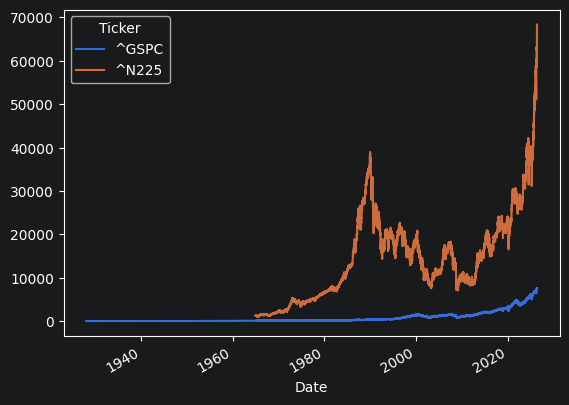

In [25]:
asset_data_yf['Close'].plot()

In [26]:
asset_data_yf.to_excel('yfdata.xlsx')

In [40]:
get_data_from_tradingview(
    tickers = ['DJI'],
    interval = Interval.in_daily,
    exchange = ['DJCFD'],
    n_bars = 14000,
    verbose = True,
    num_trials = 5,
    multi_level_index = False,
    tz_cleansing = True
)

100%|██████████| 1/1 [00:02<00:00,  2.58s/it]


field,close,high,low,open,volume
ticker,DJI,DJI,DJI,DJI,DJI
datetime,,,,,
1970-11-25,774.71,780.94,768.48,772.73,13490000.0
1970-11-27,781.35,783.61,771.15,774.71,10130000.0
1970-11-30,794.09,797.51,780.26,781.35,17700000.0
1970-12-01,794.29,805.65,787.45,794.09,20170000.0
1970-12-02,802.64,805.72,787.86,794.29,17960000.0
...,...,...,...,...,...
2026-06-01,51078.89,51161.10,50767.32,51161.10,625100000.0
2026-06-02,51307.80,51369.61,50829.55,50912.84,545500000.0


In [46]:
data = get_data_from_tradingview(
    tickers = list(asset_data.keys()),
    interval = Interval.in_daily,
    exchange = list(asset_data.values()),
    n_bars = 13000,
    column = 'close',
    verbose = True,
    num_trials = 5,
    multi_level_index = False,
    tz_cleansing = True
)

 82%|████████▏ | 9/11 [00:28<00:06,  3.37s/it]ERROR:tvDatafeed.main:Connection timed out
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
ERROR:tvDatafeed.main:Connection timed out
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
ERROR:tvDatafeed.main:Connection timed out
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
ERROR:tvDatafeed.main:Connection timed out
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
ERROR:tvDatafeed.main:Connection timed out
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
 91%|█████████ | 10/11 [01:03<00:13, 13.11s/it]

[FAIL] NIKKEI225 (Nikkei) after 5 trials: Empty data returned for NIKKEI225 (Nikkei).


ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
100%|██████████| 11/11 [01:06<00:00,  6.09s/it]
C:\Users\krm\AppData\Local\Temp\ipykernel_17168\1355288727.py:143: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(series_list, axis=1).sort_index()


In [40]:
data

,KOSPI,KOSPI200,KOSDAQ,KOSDAQ150,SPX,IXIC,NDQ,DJI,SX5E,NI225,000001
datetime,,,,,,,,,,,
1973-09-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4587.40,NaN
1973-09-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4646.37,NaN
1973-09-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4620.91,NaN
1973-09-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4644.12,NaN
1973-09-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4623.79,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-05-20,7208.95,1125.51,1056.07,1773.46,7432.96,26270.3593,29297.6982,50013.9909,5976.08,59804.19,4162.1845
2026-05-21,7815.59,1225.22,1105.97,1875.52,7445.73,26293.0975,29357.2721,50291.0186,5960.33,61683.92,4077.2765
2026-05-22,7847.71,1226.03,1161.13,1991.85,7473.48,26343.9704,29481.6417,50585.0680,6019.46,63338.85,4112.8996


In [41]:
data.columns = [
    'KOSPI','KOSPI200','KOSDAQ','KOSDAQ150','SNP500','NASDAQ','NASDAQ100','DOW_JONES','EURO_STOXX_50','NIKKEI_225','SHANGHAI_COMP'
]

In [42]:
out_data = data.copy('deep')

In [43]:
out_data.index = out_data.index.strftime('%Y-%m-%d')

In [44]:
out_data.to_excel('indexes.xlsx')

In [17]:
data_long = data.loc['2020':].unstack().reset_index()

In [18]:
data_long.columns = ['INDC_CD','BASE_YMD','INDX_VAL']

In [20]:
data_long.dropna()

,INDC_CD,BASE_YMD,INDX_VAL
0,KOSPI,2020-01-02,2175.1699
1,KOSPI,2020-01-03,2176.4600
2,KOSPI,2020-01-06,2155.0701
3,KOSPI,2020-01-07,2175.5400
4,KOSPI,2020-01-08,2151.3101
...,...,...,...
16625,SHANGHAI_COMP,2026-05-18,4131.5276
16626,SHANGHAI_COMP,2026-05-19,4169.5378
16627,SHANGHAI_COMP,2026-05-20,4162.1845
16628,SHANGHAI_COMP,2026-05-21,4077.2765


### USBONDS

In [2]:
bonds_tickers = {
    'DGS2' : 'FRED',
    'DGS10' : 'FRED',
    'DGS30' : 'FRED'
}

In [3]:
bonds_data = get_data_from_tradingview(
    tickers = list(bonds_tickers.keys()),
    interval = Interval.in_daily,
    exchange = list(bonds_tickers.values()),
    n_bars = 10000,
    column = 'close',
    verbose = True,
    num_trials = 5,
    multi_level_index = False,
    tz_cleansing = True
)

100%|██████████| 3/3 [00:27<00:00,  9.08s/it]


In [4]:
bonds_data.index = bonds_data.index.strftime('%Y-%m-%d')

In [5]:
bonds_data.to_excel('bonds_us_fred.xlsx')

### Dollar Index

In [2]:
currency_tickers = {
    'DXY' : 'TVC',
    'JXY' : 'TVC',
    'EXY' : 'TVC',
    'BXY' : 'TVC',
    'SXY' : 'TVC',
    'CXY' : 'TVC',
    'AXY' : 'TVC',
    'ZXY' : 'TVC'
}

In [36]:
currency_tickers = {
    'DXY' : 'ICEUS',
    'JXY' : 'TVC',
    'EXY' : 'TVC',
    'ZXY': 'TVC',
    'USDKRW' : 'FX_IDC',
    'EURUSD' : 'FX_IDC',
    'USDGBP' : 'FX_IDC'
}

In [33]:
currency_data = get_data_from_tradingview(
    tickers = list(currency_tickers.keys()),
    interval = Interval.in_daily,
    exchange = list(currency_tickers.values()),
    n_bars = 10000,
    column = 'close',
    verbose = True,
    num_trials = 5,
    multi_level_index = False,
    tz_cleansing = True
)

  0%|          | 0/7 [00:00<?, ?it/s]ERROR:tvDatafeed.main:Connection timed out
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
 29%|██▊       | 2/7 [00:15<00:33,  6.74s/it]ERROR:tvDatafeed.main:Connection timed out
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
100%|██████████| 7/7 [00:43<00:00,  6.20s/it]
C:\Users\krm\AppData\Local\Temp\ipykernel_32448\882957812.py:192: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(series_list, axis=1).sort_index()


In [38]:
currency_data

,DXY,JXY,EXY,ZXY,USDKRW,EURUSD,USDGBP
datetime,,,,,,,
1987-01-02,103.610,NaN,NaN,NaN,NaN,NaN,NaN
1987-01-05,104.140,NaN,NaN,NaN,NaN,NaN,NaN
1987-01-06,103.700,NaN,NaN,NaN,NaN,NaN,NaN
1987-01-07,104.080,NaN,NaN,NaN,NaN,NaN,NaN
1987-01-08,103.560,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-06-15,99.662,62.3741,115.915,58.2755,1513.97,1.15893,0.74567
2026-06-16,99.540,62.3243,116.115,58.2800,1508.46,1.16080,0.74460
2026-06-17,100.388,62.2481,115.045,57.6865,1525.64,1.15031,0.75246


<Axes: xlabel='datetime'>

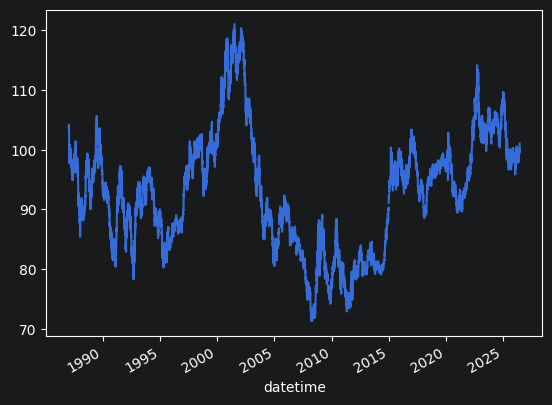

In [37]:
currency_data['DXY'].plot()

In [29]:
currency_data.index = currency_data.index.strftime('%Y-%m-%d')

In [30]:
currency_data.to_excel('currency_data.xlsx')

### Commodity Futures

In [32]:
commodity_tickers = {
    'GC1!' : 'COMEX', # Gold
    'SI1!' : 'COMEX', # Silver
    'HG1!' : 'COMEX', # Copper
    'CL1!' : 'NYMEX', # Crude Oil
    'NG1!' : 'NYMEX', # Natural Gas
    'ZW1!' : 'CBOT', # Wheat
    'ZC1!' : 'CBOT', # Corn
}

In [33]:
commodity_data = get_data_from_tradingview(
    tickers = list(commodity_tickers.keys()),
    interval = Interval.in_daily,
    exchange = list(commodity_tickers.values()),
    n_bars = 10000,
    column = 'close',
    verbose = True,
    num_trials = 5,
    multi_level_index = False,
    tz_cleansing = True
)

  0%|          | 0/7 [00:00<?, ?it/s]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
100%|██████████| 7/7 [00:20<00:00,  2.94s/it]
C:\Users\krm\AppData\Local\Temp\ipykernel_17168\1355288727.py:143: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(series_list, axis=1).sort_index()


In [36]:
commodity_data.index = commodity_data.index.strftime('%Y-%m-%d')

In [37]:
commodity_data.to_excel('commodity_data.xlsx')

In [30]:
commodity_symbols = [
    "ZW1!",
    "ZC1!",
    "ZS1!",
    "ZM1!",
    "ZL1!",
    "ZR1!",
    "ZO1!",
    "BARLEYJPR1!",
    "RS1!",
    #"RS1!",
    "FCPO1!",
    "SB1!",
    "W1!",
    "KC1!",
    "CC1!",
    "CT1!",
    "OJ1!",
    "TSR21!",
    "LBR1!",
    "LE1!",
    "GF1!",
    "HE1!",
    "DC1!",
    "BTR1!",
    "CSC1!",
    "CL1!",
    "BRN1!",
    "DBI1!",
    "NG1!",
    "RB1!",
    "HO1!",
    "G1!",
    "NCF1!",
    "UX1!",
    "EL1!",
    "GC1!",
    "SI1!",
    "PL1!",
    "PA1!",
    "HG1!",
    "ALI1!",
    #"ZINC1!",
    #"PB1!",
    #"NICKEL1!",
    #"SN1!",
    "COB1!",
    "LTH1!",
    "LTC1!",
    "TIO1!",
    #"SR1!",
    "HRC1!",
    #"CARBON1!",
]

In [31]:
exchanges = [
    "CBOT",
    "CBOT",
    "CBOT",
    "CBOT",
    "CBOT",
    "CBOT",
    "CBOT",
    "NCDEX",
    "ICEUS",
    #"ZCE",
    "MYX",
    "ICEUS",
    "ICEEUR",
    "ICEUS",
    "ICEUS",
    "ICEUS",
    "ICEUS",
    "TOCOM",
    "CME",
    "CME",
    "CME",
    "CME",
    "CME",
    "NZX",
    "CME",
    "NYMEX",
    "ICEEUR",
    "ICEEUR",
    "NYMEX",
    "NYMEX",
    "NYMEX",
    "ICEEUR",
    "ICEEUR",
    "COMEX",
    "NYMEX",
    "COMEX",
    "COMEX",
    "NYMEX",
    "NYMEX",
    "COMEX",
    "COMEX",
    #"MCX",
    #"LME",
    #"CAPITALCOM",
    #"LME",
    "COMEX",
    "COMEX",
    "COMEX",
    "COMEX",
    #"LME",
    "COMEX",
    #"CMC",
]

In [32]:
len(commodity_symbols)

45

In [37]:
commodity_data = get_data_from_tradingview(
    tickers = commodity_symbols,
    interval = Interval.in_daily,
    exchange = exchanges,
    n_bars = 13000,

    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

  7%|▋         | 3/45 [00:10<02:31,  3.61s/it]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
 29%|██▉       | 13/45 [00:34<00:50,  1.59s/it]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
 33%|███▎      | 15/45 [00:38<00:53,  1.78s/it]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
100%|██████████| 45/45 [01:10<00:00,  1.56s/it]
C:\Users\Geust\AppData\Local\Temp\ipykernel_24284\882957812.py:200: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  out = pd.concat(frames, axis=1).sort_index()


In [44]:
with pd.ExcelWriter('commodity_futures_data.xlsx') as writer:
    for symbol in commodity_symbols:
        commodity_data[symbol].dropna(axis=0, how="all").to_excel(
            writer,
            sheet_name = symbol
        )

In [2]:
import numpy as np
import pandas as pd
import pandas_datareader as pdr

us02y = pdr.DataReader(
    'DGS02',
    data_source='FRED',
    start = '1990-01-01'
)

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

### Volatilities Option

In [46]:
vol_symbols = {
    'VIX' : 'CBOE', # S&P500 Volatility
    'VVIX' : 'CBOE', # VIX Volatility
    'GAMMA' : 'CBOE', # Realized Volatility
    'SKEW' : 'CBOE', # CBOE Skewness Index
    'VXN' : 'CBOE', # Nasdaq100 Volatility
    'MOVE' : 'ICE', # ICE US Bond Volatility Index
    'GVZ' : 'CBOE', # Gold Volatility
    'VXGDX' : 'CBOE', # Gold Miner Volatility
    'OVX' : 'CBOE', # Oil Volatility
    'VXSLV' : 'CBOE', # Silver Volatility
    'VXEEM' : 'CBOE', # Emerging Market Volatility
    'VOLATILITY' : 'KRX', # VKOSPI
    'BITVX' : 'CBOE' # Bitcoin Volatility
}

In [57]:
volatility_data = get_data_from_tradingview(
    tickers = list(vol_symbols.keys()),
    interval = Interval.in_daily,
    exchange = list(vol_symbols.values()),
    n_bars = 10000,
    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

100%|██████████| 13/13 [00:25<00:00,  1.94s/it]
C:\Users\Geust\AppData\Local\Temp\ipykernel_24284\882957812.py:200: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  out = pd.concat(frames, axis=1).sort_index()


In [63]:
volatility_data['VIX'].dropna(axis = 0, how = 'all').to_excel('VIX.xlsx')
volatility_data['VVIX'].dropna(axis = 0, how = 'all').to_excel('VVIX.xlsx')
volatility_data['GAMMA'].dropna(axis = 0, how = 'all').to_excel('GAMMA.xlsx')
volatility_data['SKEW'].dropna(axis = 0, how = 'all').to_excel('SKEW.xlsx')
volatility_data['VXN'].dropna(axis = 0, how = 'all').to_excel('VXN.xlsx')
volatility_data['MOVE'].dropna(axis = 0, how = 'all').to_excel('MOVE.xlsx')
volatility_data['GVZ'].dropna(axis = 0, how = 'all').to_excel('GVZ.xlsx')
volatility_data['VXGDX'].dropna(axis = 0, how = 'all').to_excel('VXGDX.xlsx')
volatility_data['OVX'].dropna(axis = 0, how = 'all').to_excel('OVX.xlsx')
volatility_data['VXSLV'].dropna(axis = 0, how = 'all').to_excel('VXSLV.xlsx')
volatility_data['VXEEM'].dropna(axis = 0, how = 'all').to_excel('Emerging Market Volatility.xlsx')
volatility_data['VOLATILITY'].dropna(axis = 0, how = 'all').to_excel('VKOSPI.xlsx')
volatility_data['BITVX'].dropna(axis = 0, how = 'all').to_excel('Bitcoin Volatility.xlsx')

<Axes: >

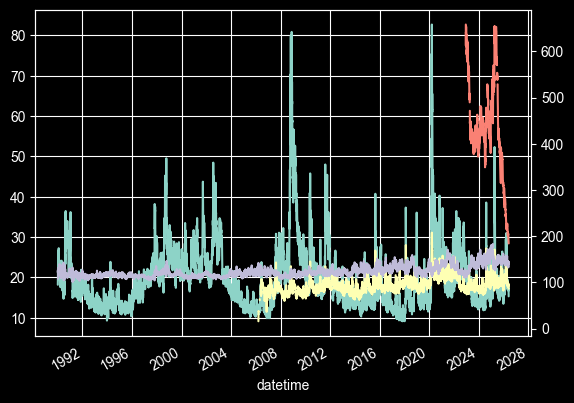

In [56]:
volatility_data['close']['VIX'].plot()
volatility_data['close']['VVIX'].plot(secondary_y = True)
volatility_data['close']['SKEW'].plot(secondary_y = True)
volatility_data['close']['GAMMA'].plot(secondary_y = True)

In [64]:
vol_symbols = {
    'VHSI' : 'HSI'
}

In [65]:
volatility_data = get_data_from_tradingview(
    tickers = list(vol_symbols.keys()),
    interval = Interval.in_daily,
    exchange = list(vol_symbols.values()),
    n_bars = 10000,
    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

100%|██████████| 1/1 [00:01<00:00,  1.71s/it]


In [69]:
volatility_data['VHSI'].to_excel('VHSI.xlsx')

In [83]:
commodity_index_symbol = {
    'SPGSCI' : 'SPCFD',
    'TRJEFFCRB' : 'TVC',
    'DJCIGC' : 'DJCFD', # Gold
    'DJCICC' : 'DJCFD', # Cocoa
    'DJCISB' : 'DJCFD', # Sugar
    'DJCIGR' : 'DJCFD', # Grains
    'DJCIKC' : 'DJCFD', # Coffee
    'DJCISI' : 'DJCFD', # Silver
    'DJCIIK' : 'DJCFD', # Nickel
    'DJCIEN' : 'DJCFD', # Energy
    'DJCIWHT' : 'DJCFD', # Wheat
    'DJCIAGC' : 'DJCFD' # Agriculture Capped Components
}

In [84]:
commodity_index_data = get_data_from_tradingview(
    tickers = list(commodity_index_symbol.keys()),
    interval = Interval.in_daily,
    exchange = list(commodity_index_symbol.values()),
    n_bars = 13000,
    verbose = True,
    num_trials = 5,
    multi_level_index = True,
    tz_cleansing = True
)

 33%|███▎      | 4/12 [00:09<00:18,  2.25s/it]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
100%|██████████| 12/12 [00:28<00:00,  2.37s/it]
C:\Users\Geust\AppData\Local\Temp\ipykernel_24284\882957812.py:200: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  out = pd.concat(frames, axis=1).sort_index()


In [85]:
with pd.ExcelWriter('commodity_index_data.xlsx') as writer:
    for symbol in list(commodity_index_symbol.keys()):
        commodity_index_data[symbol].dropna(axis=0, how="all").to_excel(
            writer,
            sheet_name = symbol
        )